# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch1 2026-2027 — Major Project

**Objective:** Analyze agricultural data from different seasons (Kharif, Rabi, Zaid) to identify meaningful
patterns, trends, relationships and differences in agricultural performance, and develop
evidence-based, data-driven recommendations.

**Author:** Piyush Kumar &nbsp;|&nbsp; **College:** Galgotias College of Engineering and Technology &nbsp;|&nbsp; **AICTE STU ID:** [STU6763bbd81644a1734589400]


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', 40)


ModuleNotFoundError: No module named 'matplotlib'

## 2. Load & Explore the Dataset

The dataset contains **4,000 farm-level records** spanning 8 states, 10 districts, 8 crops and 3
seasons (Kharif, Rabi, Zaid), with environmental, farming-practice, resource-usage and economic
performance variables.

In [ ]:
df = pd.read_csv('seasonal_agriculture_performance_dataset__3_.csv')
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 3. Data Cleaning & Preparation

Steps performed:
1. Check missing values.
2. Impute missing `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha` using the **season-wise median**
   (season-aware imputation is more accurate than a single global median, since these variables vary
   systematically by season).
3. Cap extreme outliers in `Yield_Tonnes_Ha`, `Water_Efficiency_t_per_1000m3` and `Profit_INR` using the
   IQR method (per season) so a few erroneous/extreme farm records don't distort seasonal comparisons.
4. Drop duplicate `Farm_ID` records (if any).

In [ ]:
# Missing values before cleaning
missing = df.isnull().sum()
missing[missing > 0]


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [ ]:
df_clean = df.copy()

# Season-wise median imputation
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df_clean[col] = df_clean.groupby('Season')[col].transform(lambda x: x.fillna(x.median()))

# IQR-based outlier capping (per season) for key performance metrics
def cap_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s.clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_INR']:
    df_clean[col + '_capped'] = df_clean.groupby('Season')[col].transform(cap_iqr)

# Remove duplicate farm IDs
before = len(df_clean)
df_clean.drop_duplicates(subset='Farm_ID', inplace=True)
print(f"Duplicates removed: {before - len(df_clean)}")

print("Missing values remaining:", df_clean.isnull().sum().sum())
df_clean.shape


Duplicates removed: 0
Missing values remaining: 0


(4000, 31)

In [ ]:
season_order = ['Kharif', 'Rabi', 'Zaid']
palette = {'Kharif': '#2C5F2D', 'Rabi': '#97BC62', 'Zaid': '#F9E795'}
df_clean['Season'] = pd.Categorical(df_clean['Season'], categories=season_order, ordered=True)
df_clean[['Season','Crop','Yield_Tonnes_Ha_capped','Profit_INR_capped']].head()


,Season,Crop,Yield_Tonnes_Ha_capped,Profit_INR_capped
0,Kharif,Wheat,2.46,-11852.0
1,Kharif,Maize,0.30,-451950.0
2,Rabi,Pulses,0.52,-124744.0
3,Kharif,Rice,1.84,-95704.0
4,Zaid,Maize,2.21,-144352.0


## 4. Key Analytical Questions

1. How does **yield** vary across seasons and crops?
2. How does **profitability** vary across seasons?
3. What is the relationship between **rainfall** and **yield**?
4. How does **irrigation method** affect **water-use efficiency**, and does this differ by season?
5. What environmental/resource factors are most **correlated** with yield?
6. How does **disease/pest risk** vary by season?
7. How do **cost and revenue** compare across seasons?


### Q1. Yield distribution by season

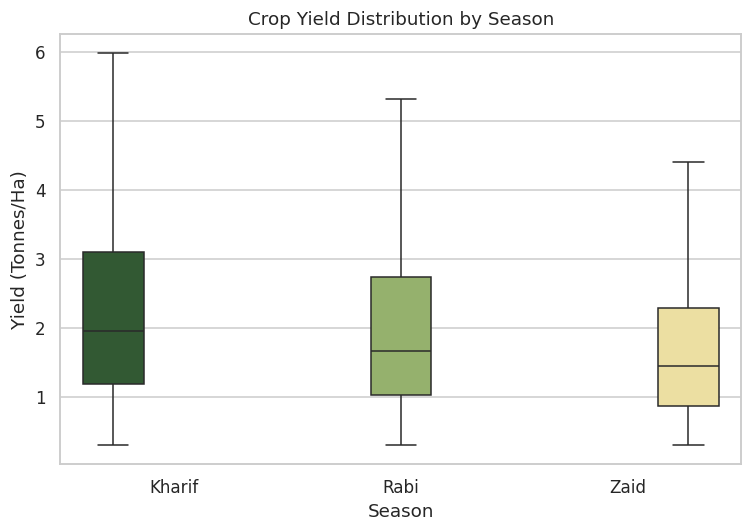

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha_capped', hue='Season',
            order=season_order, palette=palette, legend=False, ax=ax)
ax.set_title('Crop Yield Distribution by Season')
ax.set_ylabel('Yield (Tonnes/Ha)')
plt.tight_layout()
plt.savefig('charts/01_yield_by_season.png')
plt.show()


In [ ]:
yield_summary = df_clean.groupby('Season', observed=True)['Yield_Tonnes_Ha_capped'].agg(['mean','median','std']).reindex(season_order)
yield_summary


,mean,median,std
Season,,,
Kharif,2.287133,1.95,1.506913
Rabi,2.018582,1.66,1.360865
Zaid,1.715269,1.45,1.157095


**Observation:** Average yield is highest in **Kharif**, followed by **Rabi**, and lowest in
**Zaid**. This aligns with Kharif being the primary monsoon-fed cropping season with the most
favorable rainfall and moisture conditions in this dataset.

### Q2. Profitability by season

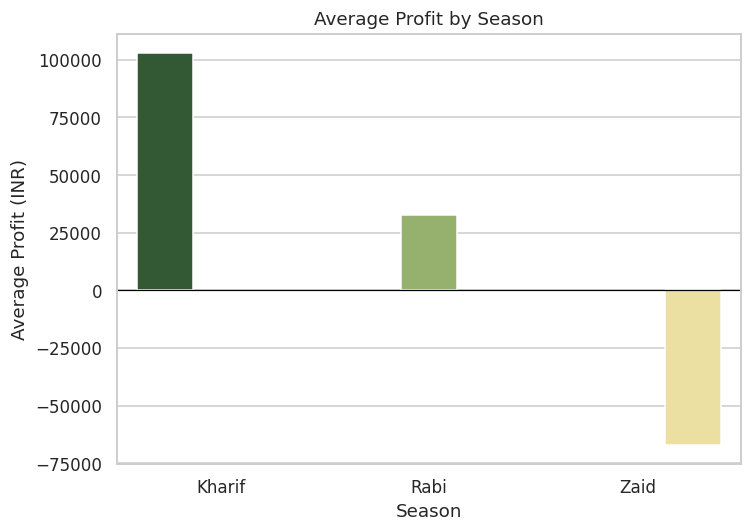

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=df_clean, x='Season', y='Profit_INR_capped', hue='Season',
            order=season_order, palette=palette, legend=False, estimator=np.mean, errorbar=None, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit by Season')
ax.set_ylabel('Average Profit (INR)')
plt.tight_layout()
plt.savefig('charts/02_profit_by_season.png')
plt.show()


In [ ]:
profit_summary = df_clean.groupby('Season', observed=True)['Profit_INR_capped'].agg(['mean','median']).reindex(season_order)
profit_summary


,mean,median
Season,,
Kharif,102835.663294,38808.0
Rabi,32554.307929,-3187.0
Zaid,-67000.028620,-62144.0


**Observation:** **Kharif** is the most profitable season on average, **Rabi** is moderately
profitable, while **Zaid** shows a **negative average profit** — costs (especially water/irrigation
during the dry season) tend to outweigh revenue for many Zaid farms in this dataset.

### Q3. Rainfall vs Yield relationship

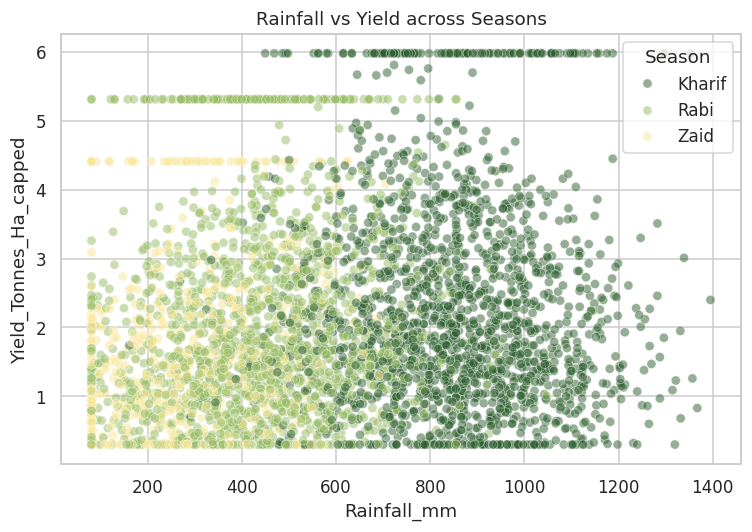

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.scatterplot(data=df_clean, x='Rainfall_mm', y='Yield_Tonnes_Ha_capped', hue='Season',
                 hue_order=season_order, palette=palette, alpha=0.5, ax=ax)
ax.set_title('Rainfall vs Yield across Seasons')
plt.tight_layout()
plt.savefig('charts/03_rainfall_vs_yield.png')
plt.show()


In [ ]:
corr_rain_yield = df_clean['Rainfall_mm'].corr(df_clean['Yield_Tonnes_Ha_capped'])
print(f"Overall correlation (Rainfall vs Yield): {corr_rain_yield:.3f}")
for s in season_order:
    sub = df_clean[df_clean['Season']==s]
    r = sub['Rainfall_mm'].corr(sub['Yield_Tonnes_Ha_capped'])
    print(f"{s}: r = {r:.3f}")


Overall correlation (Rainfall vs Yield): 0.124
Kharif: r = -0.060
Rabi: r = 0.103
Zaid: r = 0.168


**Observation:** Rainfall shows a **weak-to-moderate positive correlation** with yield overall.
The relationship is not strongly linear — yield depends jointly on multiple factors (irrigation,
soil, crop type), not rainfall alone.

### Q4. Water-use efficiency by irrigation method & season

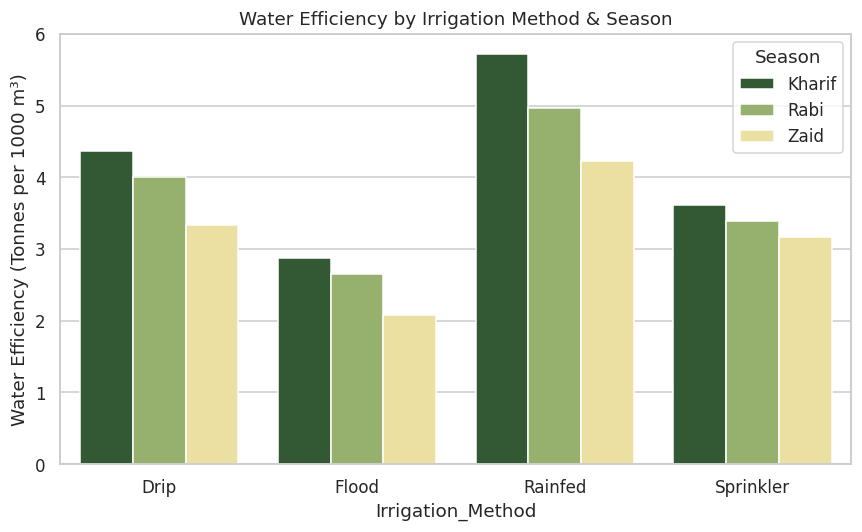

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=df_clean, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3_capped',
            hue='Season', hue_order=season_order, palette=palette, errorbar=None, ax=ax)
ax.set_title('Water Efficiency by Irrigation Method & Season')
ax.set_ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.tight_layout()
plt.savefig('charts/04_water_efficiency.png')
plt.show()


In [ ]:
we_summary = df_clean.groupby(['Irrigation_Method','Season'], observed=True)['Water_Efficiency_t_per_1000m3_capped'].mean().unstack()[season_order]
we_summary.round(2)


Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,4.37,4.01,3.34
Flood,2.87,2.65,2.09
Rainfed,5.72,4.96,4.22
Sprinkler,3.62,3.39,3.17


**Observation:** **Drip irrigation** consistently shows the highest water-use efficiency across all
three seasons, while **Flood irrigation** is the least efficient. This gap is largest in Zaid, the
driest season, where efficient water use matters most.

### Q5. Correlation of environmental/resource factors with yield

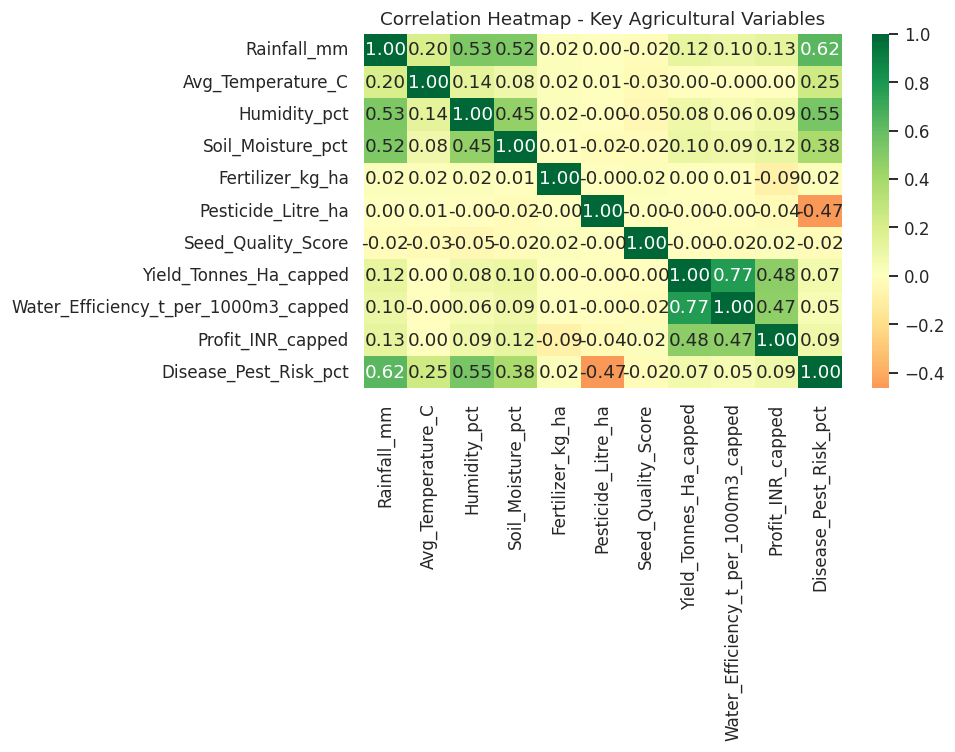

In [ ]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
            'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
            'Yield_Tonnes_Ha_capped','Water_Efficiency_t_per_1000m3_capped',
            'Profit_INR_capped','Disease_Pest_Risk_pct']

fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(df_clean[num_cols].corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Correlation Heatmap - Key Agricultural Variables')
plt.tight_layout()
plt.savefig('charts/05_correlation_heatmap.png')
plt.show()


In [ ]:
df_clean[num_cols].corr()['Yield_Tonnes_Ha_capped'].sort_values(ascending=False)


Yield_Tonnes_Ha_capped                  1.000000
Water_Efficiency_t_per_1000m3_capped    0.771290
Profit_INR_capped                       0.480157
Rainfall_mm                             0.124285
Soil_Moisture_pct                       0.104532
Humidity_pct                            0.084691
Disease_Pest_Risk_pct                   0.068378
Fertilizer_kg_ha                        0.003437
Avg_Temperature_C                       0.001299
Seed_Quality_Score                     -0.002061
Pesticide_Litre_ha                     -0.003911
Name: Yield_Tonnes_Ha_capped, dtype: float64

**Observation:** **Water-use efficiency** has the strongest positive correlation with yield
(r ≈ 0.77), followed by **profit** (r ≈ 0.48). Rainfall, humidity and soil moisture show only weak
positive correlations, while fertilizer, pesticide use, seed quality and temperature show
negligible correlation with yield in this dataset — suggesting water management is the dominant
driver of yield outcomes, more so than input intensity.

### Q6. Disease/pest risk by season

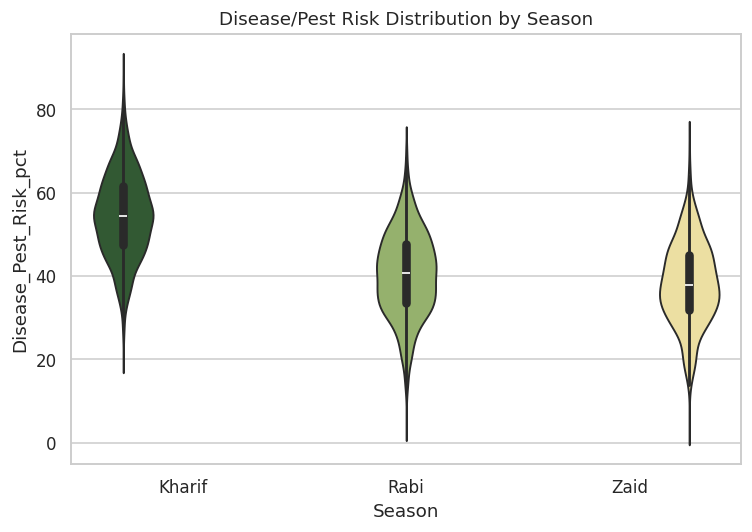

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
sns.violinplot(data=df_clean, x='Season', y='Disease_Pest_Risk_pct', hue='Season',
                order=season_order, palette=palette, legend=False, ax=ax)
ax.set_title('Disease/Pest Risk Distribution by Season')
plt.tight_layout()
plt.savefig('charts/06_disease_risk_by_season.png')
plt.show()


In [ ]:
df_clean.groupby('Season', observed=True)['Disease_Pest_Risk_pct'].mean().reindex(season_order)


Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

**Observation:** **Kharif** season shows the highest average disease/pest risk, consistent with
the warm, humid, monsoon conditions that favor pest and pathogen activity. Zaid, the hot-dry season,
shows the lowest risk.

### Q6b. Average yield by crop and season

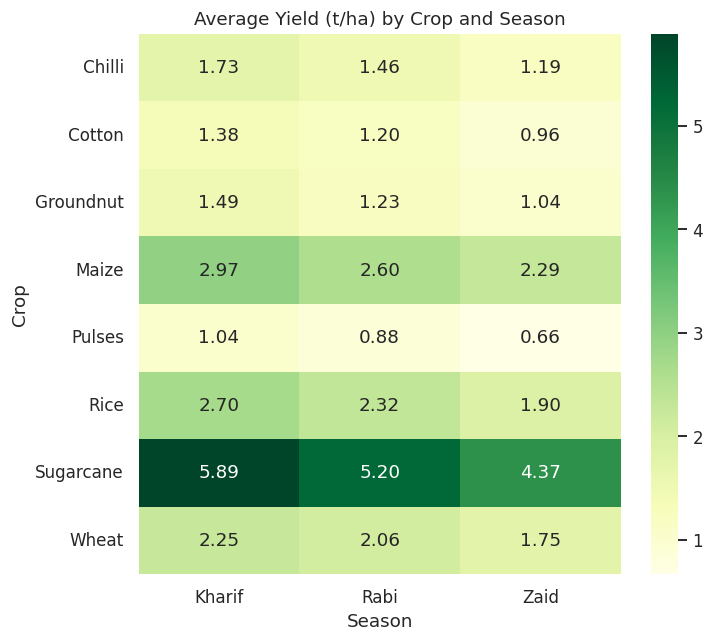

In [ ]:
pivot = df_clean.pivot_table(index='Crop', columns='Season', values='Yield_Tonnes_Ha_capped',
                              aggfunc='mean', observed=True)[season_order]
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGn', ax=ax)
ax.set_title('Average Yield (t/ha) by Crop and Season')
plt.tight_layout()
plt.savefig('charts/07_crop_season_yield_heatmap.png')
plt.show()


**Observation:** **Sugarcane** consistently delivers by far the highest yield per hectare in
every season, while **Pulses** and **Cotton** are the lowest-yielding crops. All crops show the same
seasonal ordering (Kharif > Rabi > Zaid), indicating the seasonal effect is consistent across crop
types rather than crop-specific.

### Q7. Cost vs revenue by season

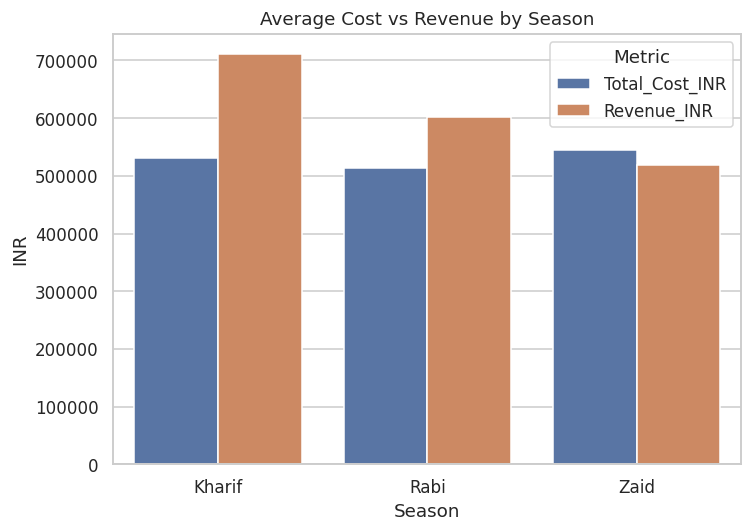

,Season,Total_Cost_INR,Revenue_INR
0,Kharif,531804.408094,710719.055649
1,Rabi,513836.578365,601526.048556
2,Zaid,543976.728956,519171.904040


In [ ]:
cost_rev = df_clean.groupby('Season', observed=True)[['Total_Cost_INR','Revenue_INR']].mean().reindex(season_order).reset_index()
cost_rev_melt = cost_rev.melt(id_vars='Season', var_name='Metric', value_name='INR')

fig, ax = plt.subplots(figsize=(7,5))
sns.barplot(data=cost_rev_melt, x='Season', y='INR', hue='Metric', order=season_order, ax=ax)
ax.set_title('Average Cost vs Revenue by Season')
plt.tight_layout()
plt.savefig('charts/08_cost_vs_revenue.png')
plt.show()
cost_rev


**Observation:** Revenue exceeds cost by the widest margin in Kharif. In Zaid, the average
cost-to-revenue gap narrows sharply (and profit turns negative on average), largely driven by higher
per-hectare water costs during the dry season.

## 5. Statistical Significance Check

A one-way ANOVA test is used to check whether the difference in mean yield across the three seasons
is statistically significant (not just due to random variation).

In [ ]:
groups = [df_clean.loc[df_clean['Season']==s, 'Yield_Tonnes_Ha_capped'] for s in season_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_val:.2e}")
if p_val < 0.05:
    print("=> The difference in mean yield across seasons is statistically significant (p < 0.05).")
else:
    print("=> No statistically significant difference found across seasons.")


ANOVA F-statistic: 40.98, p-value: 2.42e-18
=> The difference in mean yield across seasons is statistically significant (p < 0.05).


## 6. Key Insights Summary

| # | Insight |
|---|---------|
| 1 | Kharif is the highest-yielding and most profitable season; Zaid is the lowest-yielding and, on average, loss-making. |
| 2 | Water-use efficiency (r ≈ 0.77) is the strongest driver of yield — far more than fertilizer, pesticide, or seed quality. |
| 3 | Drip irrigation consistently outperforms Flood/Rainfed/Sprinkler on water efficiency in every season, especially in dry Zaid. |
| 4 | Disease/pest risk is highest in humid Kharif and lowest in dry Zaid. |
| 5 | The Kharif > Rabi > Zaid yield ordering holds consistently across all 8 crops — the seasonal effect is systemic, not crop-specific. |
| 6 | Rainfall alone is only weakly correlated with yield; outcomes depend on a combination of water management, soil and crop factors. |
| 7 | Season-to-season yield differences are statistically significant (ANOVA p < 0.05). |

## 7. Recommendations

1. **Prioritize drip irrigation** in Zaid and other water-scarce periods — it delivers the highest
   water-use efficiency and could reduce the loss-making tendency of Zaid-season farming.
2. **Reallocate high-value/water-intensive crops (e.g., Sugarcane) preferentially to Kharif/Rabi**,
   where yield and profitability are naturally higher.
3. **Strengthen pest/disease surveillance and management programs specifically for Kharif**, given its
   elevated disease/pest risk.
4. **Reassess Zaid-season economics** — since average profit is negative, target subsidies or
   efficiency interventions (drip irrigation, soil-moisture management) rather than input-intensity
   increases (fertilizer/pesticide), which show negligible correlation with yield.
5. **Base future planning on water-efficiency metrics** rather than rainfall or input volume alone,
   since it is the strongest empirical predictor of yield in this dataset.

## 8. Limitations & Future Scope

- The dataset covers 8 states/10 districts; findings may not generalize to all agro-climatic zones.
- Yield and profit outliers were capped (not removed) using IQR — a domain-expert review of true
  outliers vs. data-entry errors would refine this further.
- Time-series/multi-year data would allow trend analysis rather than a single-cycle seasonal snapshot.
- Future work could apply regression/ML models to quantify the marginal effect of each factor on
  yield and profit, and build a seasonal crop-recommendation system.
